# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "png"

In [2]:
# Chargement du dataset
url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
df = pd.read_csv(url)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
# Filtre sur l'année 2016 et uniquement les médaillés (Medal non nul)
df_2016 = df[(df['Year'] == 2016) & (df['Medal'].notna())]
print(f"Nombre de médaillés en 2016 : {len(df_2016)}")

Nombre de médaillés en 2016 : 2023


In [5]:
# Nombre de médailles par sport
medals_by_sport = df_2016['Sport'].value_counts().reset_index()
medals_by_sport.columns = ['Sport', 'Medal_Count']

# Top 5
top5_sports = medals_by_sport.head(5)
print(top5_sports)

       Sport  Medal_Count
0  Athletics          192
1   Swimming          191
2     Rowing          144
3   Football          106
4     Hockey           99


In [6]:
# Filtrage du DataFrame sur les top 5 sports uniquement
top5_list = top5_sports['Sport'].tolist()
df_top5 = df_2016[df_2016['Sport'].isin(top5_list)]
print(f"Nombre de lignes pour les top 5 sports : {len(df_top5)}")

Nombre de lignes pour les top 5 sports : 732


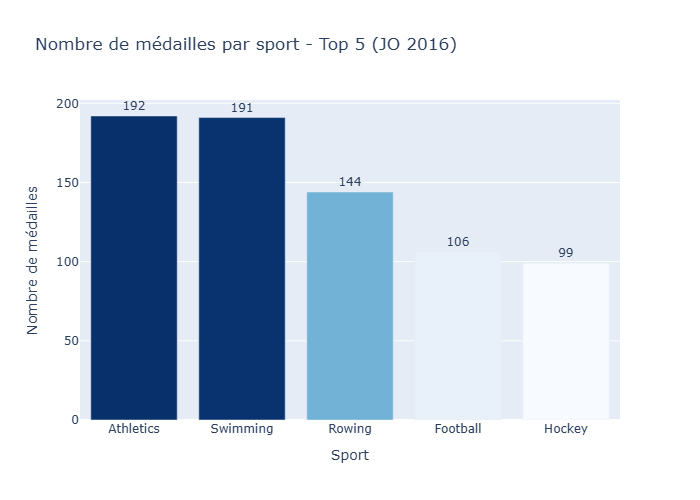

In [7]:
fig = px.bar(
    top5_sports,
    x='Sport', y='Medal_Count',
    title='Nombre de médailles par sport - Top 5 (JO 2016)',
    labels={'Sport': 'Sport', 'Medal_Count': 'Nombre de médailles'},
    color='Medal_Count',
    color_continuous_scale='Blues',
    text='Medal_Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

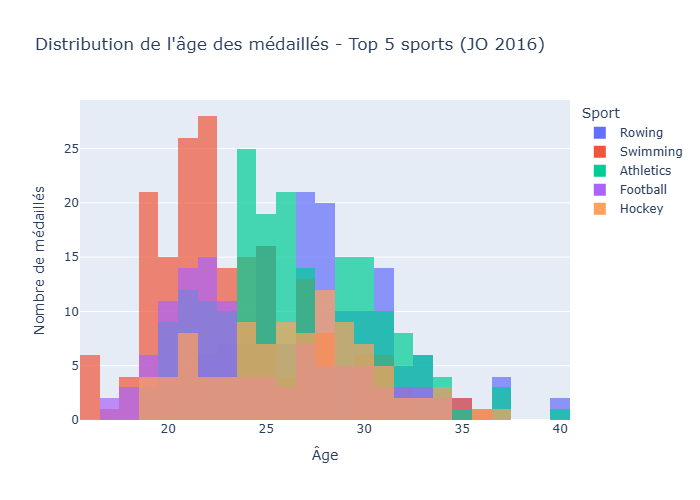

In [8]:
fig = px.histogram(
    df_top5,
    x='Age',
    color='Sport',
    nbins=30,
    title="Distribution de l'âge des médaillés - Top 5 sports (JO 2016)",
    labels={'Age': 'Âge', 'count': 'Nombre de médaillés'},
    barmode='overlay',
    opacity=0.7
)
fig.update_layout(xaxis_title='Âge', yaxis_title='Nombre de médaillés')
fig.show()

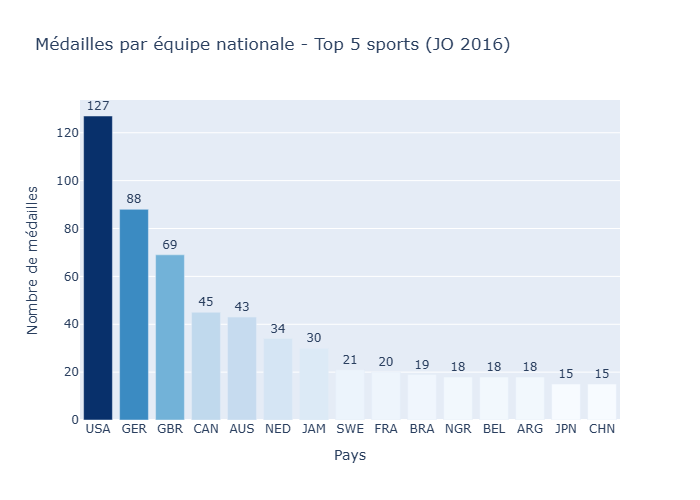

In [10]:
# Nombre de médailles par pays (top 15 pour la lisibilité)
medals_by_team = df_top5['NOC'].value_counts().reset_index()
medals_by_team.columns = ['NOC', 'Medal_Count']
medals_by_team = medals_by_team.head(15)

fig = px.bar(
    medals_by_team,
    x='NOC', y='Medal_Count',
    title='Médailles par équipe nationale - Top 5 sports (JO 2016)',
    labels={'NOC': 'Pays', 'Medal_Count': 'Nombre de médailles'},
    color='Medal_Count',
    color_continuous_scale='Blues',
    text='Medal_Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

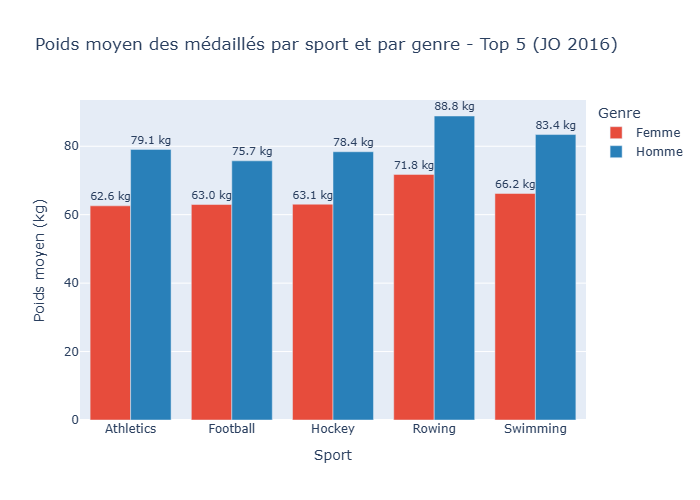

In [11]:
# Calcul du poids moyen par sport et par genre
avg_weight = df_top5.groupby(['Sport', 'Sex'])['Weight'].mean().round(2).reset_index()
avg_weight.columns = ['Sport', 'Genre', 'Poids_Moyen']

# Remplacement des codes M/F pour plus de lisibilité
avg_weight['Genre'] = avg_weight['Genre'].map({'M': 'Homme', 'F': 'Femme'})

fig = px.bar(
    avg_weight,
    x='Sport', y='Poids_Moyen',
    color='Genre',
    barmode='group',
    title='Poids moyen des médaillés par sport et par genre - Top 5 (JO 2016)',
    labels={'Sport': 'Sport', 'Poids_Moyen': 'Poids moyen (kg)', 'Genre': 'Genre'},
    color_discrete_map={'Homme': '#2980b9', 'Femme': '#e74c3c'},
    text='Poids_Moyen'
)
fig.update_traces(texttemplate='%{text:.1f} kg', textposition='outside')
fig.show()